# Libs

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb
import optuna

import pandas as pd
import plotly.express as px

import shap

In [2]:
df = pd.read_csv("./data/final_dataset_processed.csv")

print(df.shape)
df.head()

(3824, 77)


,player_id_players_source,player_id_profiles_source,name,current_club_id,current_club_name,country_of_birth,country_of_citizenship,date_of_birth,position,height_in_cm,...,sub_position_Goalkeeper,sub_position_Left Midfield,sub_position_Left Winger,sub_position_Left-Back,sub_position_Right Midfield,sub_position_Right Winger,sub_position_Right-Back,sub_position_Second Striker,foot_left,foot_right
0,3333,791,James Milner,1237,Brighton and Hove Albion Football Club,England,England,1986-01-04,Midfield,175.0,...,False,False,False,False,False,False,False,False,False,True
1,7161,142390,Jonas Hofmann,15,Bayer 04 Leverkusen Fußball,Germany,Germany,1992-07-14,Midfield,176.0,...,False,False,False,False,False,False,False,False,False,True
2,11530,122922,Lionel Carole,3205,Kayserispor Kulübü,France,France,1991-04-12,Defender,180.0,...,False,False,False,True,False,False,False,False,True,False
3,12282,44864,Daley Blind,12321,Girona Fútbol Club S. A. D.,Netherlands,Netherlands,1990-03-09,Defender,180.0,...,False,False,False,False,False,False,False,False,True,False
4,15452,3041,Raúl Albiol,4172,Pisa Sporting Club,Spain,Spain,1985-09-04,Defender,190.0,...,False,False,False,False,False,False,False,False,False,True


# General Model

In [10]:
# List of columns to drop (from your spec)
cols_to_drop = [
    # 🔑 Primary key
    "name",

    # Target variable
    "log_market_value",

    # 🔗 IDs / Technical
    "player_id_players_source",
    "player_id_profiles_source",

    # 🏟️ Club-related
    "current_club_id",
    "current_club_name",
    "club_avg_value",
    "club_avg_value_log",
    "club_avg_loo",

    # 🌍 Country-related
    "country_of_birth",
    "country_of_citizenship",
    "country_grouped",

    # 📅 Time-related
    "date_of_birth",
    "age_bucket",

    # ⚽ Position-related
    "position",
    "sub_position",

    # 🦶 Other categorical
    "foot",
    "league",

    # 🏆 Misc
    "current_national_team_id",
    "market_value_profiles",
    "market_value_in_eur",

    # 📉 Highly correlated
    "appearances",
    "matches_started",
    "goals",
    "expected_goals",
    "shots_on_target",
    "assists"
]

# Drop only columns that actually exist (safe)
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['log_market_value']

X.head()

,height_in_cm,minutes_played,expected_assists,rating,total_shots,yellow_cards,red_cards,tackles,interceptions,saves,...,sub_position_Goalkeeper,sub_position_Left Midfield,sub_position_Left Winger,sub_position_Left-Back,sub_position_Right Midfield,sub_position_Right Winger,sub_position_Right-Back,sub_position_Second Striker,foot_left,foot_right
0,175.0,743.0,0.623653,6.711111,8.0,2.0,0.0,14.0,6.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,176.0,978.0,1.770580,6.742857,21.0,3.0,0.0,13.0,2.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,180.0,1542.0,0.529125,6.645000,0.0,4.0,0.0,27.0,23.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,180.0,2303.0,1.059539,6.974074,3.0,1.0,0.0,48.0,36.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,190.0,502.0,0.293735,6.675000,1.0,1.0,0.0,7.0,6.0,0.0,...,False,False,False,False,False,False,False,False,False,True


In [11]:
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2676, 54)
Val: (574, 54)
Test: (574, 54)


In [12]:
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,

        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),

        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    return rmse

In [13]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-16 16:00:25,306] A new study created in memory with name: no-name-b9cd6d30-40eb-491a-8148-03011a6ee020
[I 2026-04-16 16:00:25,445] Trial 0 finished with value: 0.6628551969889639 and parameters: {'num_leaves': 27, 'learning_rate': 0.0460280331385561, 'n_estimators': 668, 'max_depth': 7, 'min_child_samples': 55, 'subsample': 0.6324524584395518, 'colsample_bytree': 0.6900246708730631, 'reg_alpha': 0.0023458693538108357, 'reg_lambda': 0.0018527536570484724}. Best is trial 0 with value: 0.6628551969889639.
[I 2026-04-16 16:00:25,823] Trial 1 finished with value: 0.6666896969450898 and parameters: {'num_leaves': 75, 'learning_rate': 0.010251861752955881, 'n_estimators': 1355, 'max_depth': 6, 'min_child_samples': 15, 'subsample': 0.7551493549497716, 'colsample_bytree': 0.9392423296062145, 'reg_alpha': 0.17609951740728197, 'reg_lambda': 0.5761120358626813}. Best is trial 0 with value: 0.6628551969889639.
[I 2026-04-16 16:00:25,914] Trial 2 finished with value: 0.6673970559269838 an

Best RMSE: 0.6542915101198428
Best params: {'num_leaves': 88, 'learning_rate': 0.028005195693634587, 'n_estimators': 971, 'max_depth': 10, 'min_child_samples': 85, 'subsample': 0.7558836702940027, 'colsample_bytree': 0.9500987164866432, 'reg_alpha': 0.005010051737174739, 'reg_lambda': 0.04064677966620687}


In [14]:
best_params = study.best_params

final_model = lgb.LGBMRegressor(
    **best_params,
    objective="regression"
)

# Combine train + val
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model.fit(X_train_full, y_train_full)

LGBMRegressor(colsample_bytree=0.9500987164866432,
              learning_rate=0.028005195693634587, max_depth=10,
              min_child_samples=85, n_estimators=971, num_leaves=88,
              objective='regression', reg_alpha=0.005010051737174739,
              reg_lambda=0.04064677966620687, subsample=0.7558836702940027)

In [15]:
preds = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

RMSE: 0.6938
MAE: 0.5198
R2: 0.8295


In [21]:
# Inverse transform
y_test_raw = np.expm1(y_test)
preds_raw = np.expm1(preds)

# Metrics
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, preds_raw))
mae_raw = mean_absolute_error(y_test_raw, preds_raw)
r2_raw = r2_score(y_test_raw, preds_raw)

# MAPE (safe version)
epsilon = 1e-8
mape = np.mean(np.abs((y_test_raw - preds_raw) / (y_test_raw + epsilon))) * 100

print(f"RMSE (raw €): {rmse_raw:,.2f}")
print(f"MAE (raw €): {mae_raw:,.2f}")
print(f"R2 (raw): {r2_raw:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE (raw €): 6,648,885.09
MAE (raw €): 3,323,783.81
R2 (raw): 0.7943
MAPE: 63.67%


In [22]:
# Get feature importances
importance_df = pd.DataFrame({
    "feature": X_train_full.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

# Reverse so the biggest appears at the top in horizontal bar chart
importance_df = importance_df.sort_values("importance", ascending=True)

print(importance_df)

fig = px.bar(
    importance_df,
    x="importance",
    y="feature",
    orientation="h",
    title="Top 20 Feature Importances",
    labels={"importance": "Importance", "feature": "Feature"}
)

fig.update_layout(
    yaxis_title="",
    xaxis_title="Importance",
    height=700
)

fig.show()

                    feature  importance
53               foot_right          96
34            league_LaLiga          99
37    league_Premier League         104
25    country_grouped_Other         148
35     league_Liga Portugal         156
33        league_Eredivisie         162
32  country_grouped_Türkiye         166
44  sub_position_Goalkeeper         180
17  country_grouped_England         185
36           league_Ligue 1         198
5              yellow_cards         388
8             interceptions         787
7                   tackles         989
4               total_shots        1091
0              height_in_cm        1617
2          expected_assists        1863
3                    rating        2108
10            age_years_int        2274
1            minutes_played        2639
11         club_avg_loo_log        3905


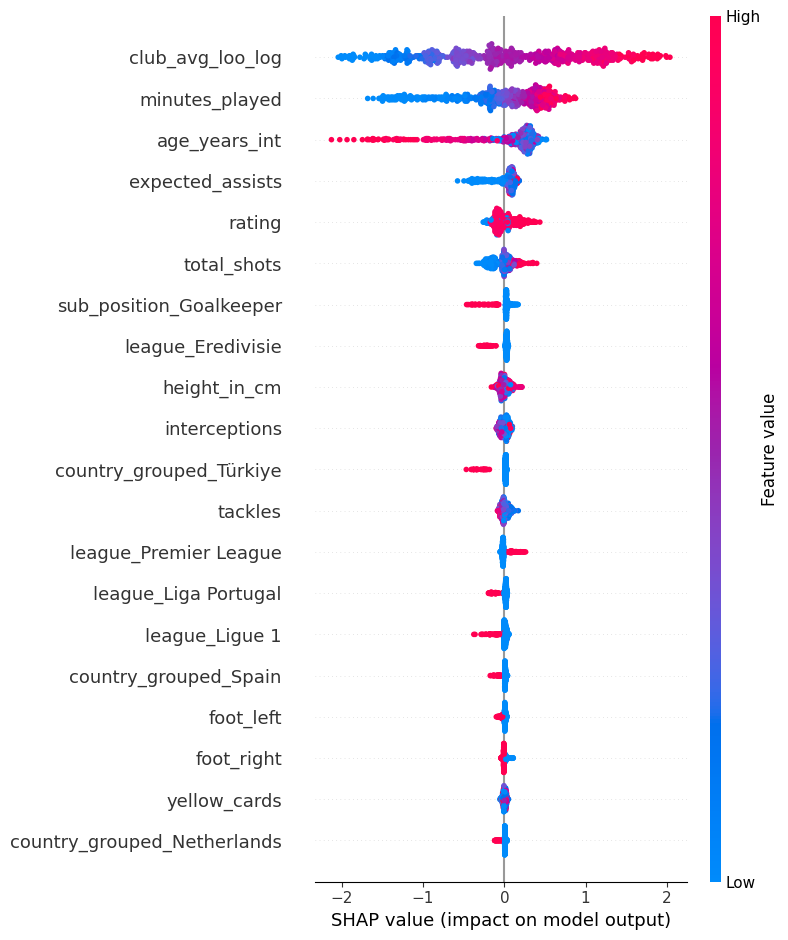

In [19]:
# Create explainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)